# Letter Kaki — Phase 1 Pipeline Check

Runs `classify_letter` and `summarize_letter` against every sample in `samples/`, showing the image alongside the pipeline output. Re-run after prompt changes to see how outputs shift.

In [1]:
import os
from pathlib import Path

if not Path("pipeline").exists():
    os.chdir("..")

from IPython.display import Image, display

from pipeline.classify import classify_letter
from pipeline.summarize import summarize_letter

SAMPLES_DIR = Path("samples")
sample_paths = sorted(SAMPLES_DIR.glob("*.jpg"))
sample_paths

[PosixPath('samples/bad_quality_photo.jpg'),
 PosixPath('samples/cpf_statement.jpg'),
 PosixPath('samples/iras_notice.jpg'),
 PosixPath('samples/polyclinic_bill.jpg'),
 PosixPath('samples/scam_letter.jpg'),
 PosixPath('samples/town_council_notice.jpg')]

## Classify + summarize every sample


bad_quality_photo.jpg


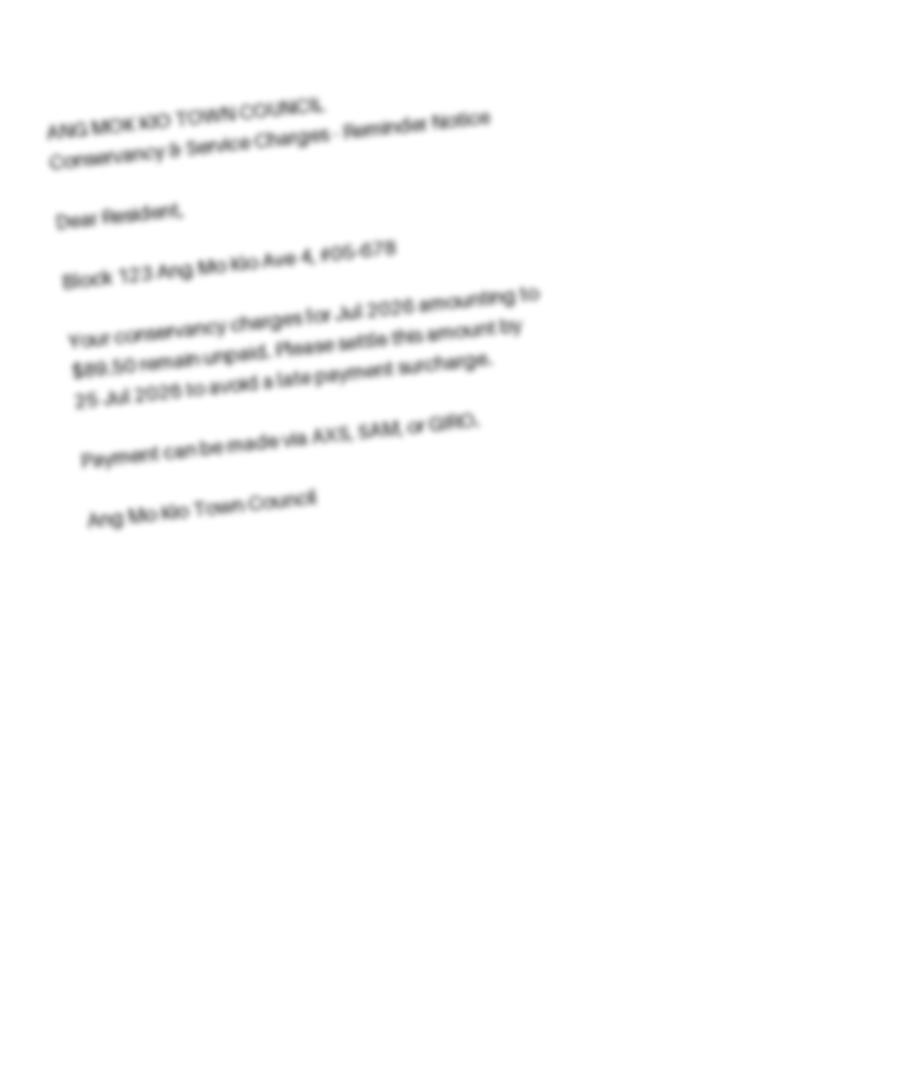

category: government



I can see this is a letter from Ang Mo Kio Town Council about community charges, but the image is too blurry and unclear for me to read the specific details with confidence.

To give you an accurate summary, I would need to see:
- The exact amount you owe
- The exact deadline date
- Any other specific details about payment

**Please check the original letter directly**, or if you can provide a clearer photo, I'll be happy to summarize it for you properly.

cpf_statement.jpg


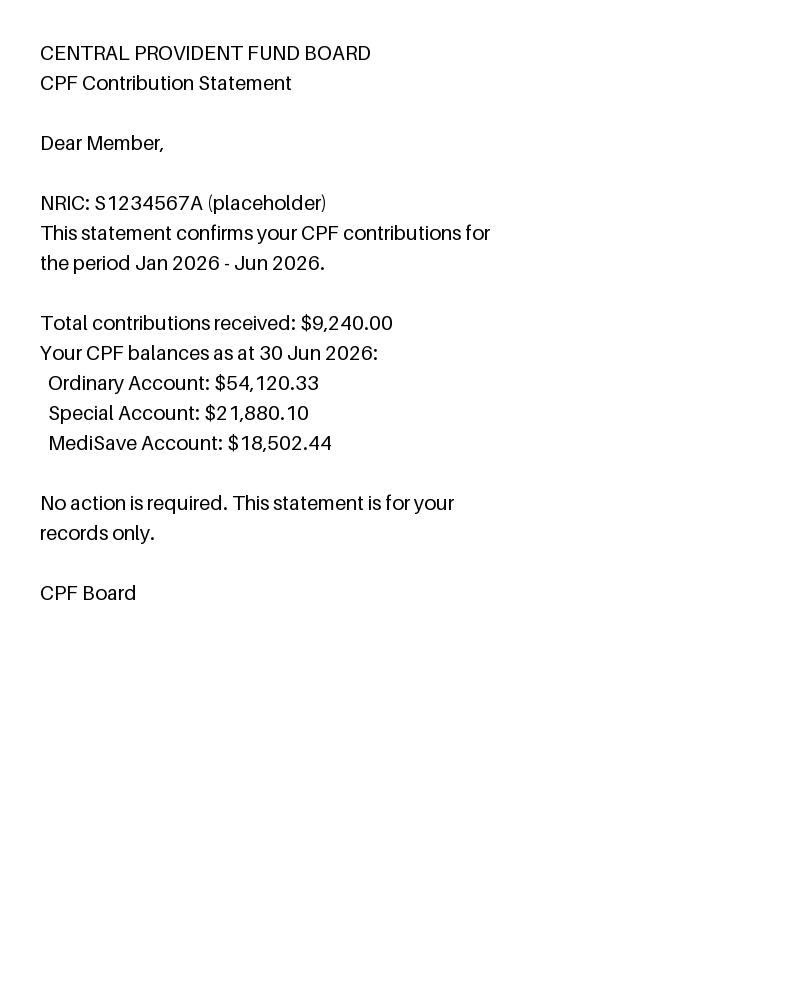

category: government



📬 This letter is from the Central Provident Fund Board (CPF).

**What it says:**
This is your CPF contribution statement for January to June 2026.
You received $9,240.00 in contributions during this period.
Your CPF account balances as of 30 June 2026 are: Ordinary Account $54,120.33, Special Account $21,880.10, and MediSave Account $18,502.44.

**What you need to do:**
Nothing! This is just for your records.

**By when:**
No action needed.

iras_notice.jpg


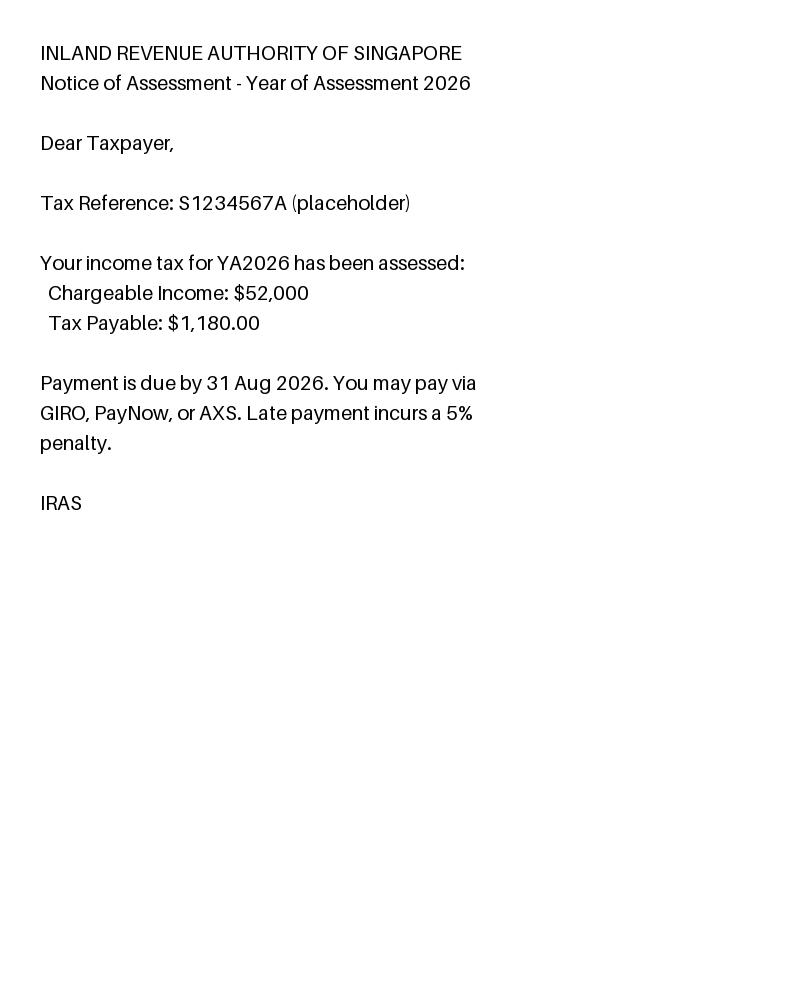

category: government



📬 This letter is from the Inland Revenue Authority of Singapore (IRAS).

**What it says:**
Your income tax for 2026 has been worked out.
You earned $52,000 and owe $1,180 in tax.
You can pay by GIRO, PayNow, or AXS.
If you pay late, there is a 5% penalty added.

**What you need to do:**
**Pay $1,180 by 31 August 2026.**

**By when:** 31 August 2026

**Amount:** $1,180.00

polyclinic_bill.jpg


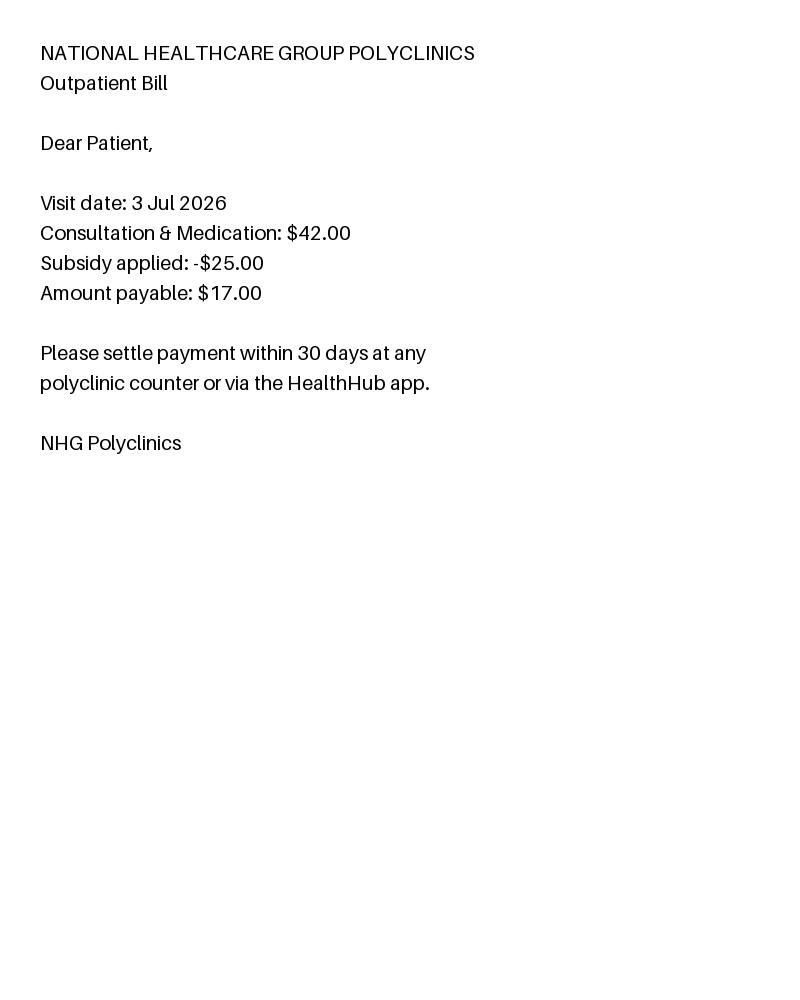

category: bill_or_medical



📬 This letter is from **National Healthcare Group Polyclinics**.

**What it says:**
You went to the polyclinic on 3 July 2026.
The cost for your visit and medicines was $42.00.
You received a subsidy of $25.00.
You now need to pay $17.00.

**What you need to do:**
**Pay $17.00** at any polyclinic counter or through the HealthHub app.

**By when:**
Within 30 days from the letter date.

**Amount: $17.00**

scam_letter.jpg


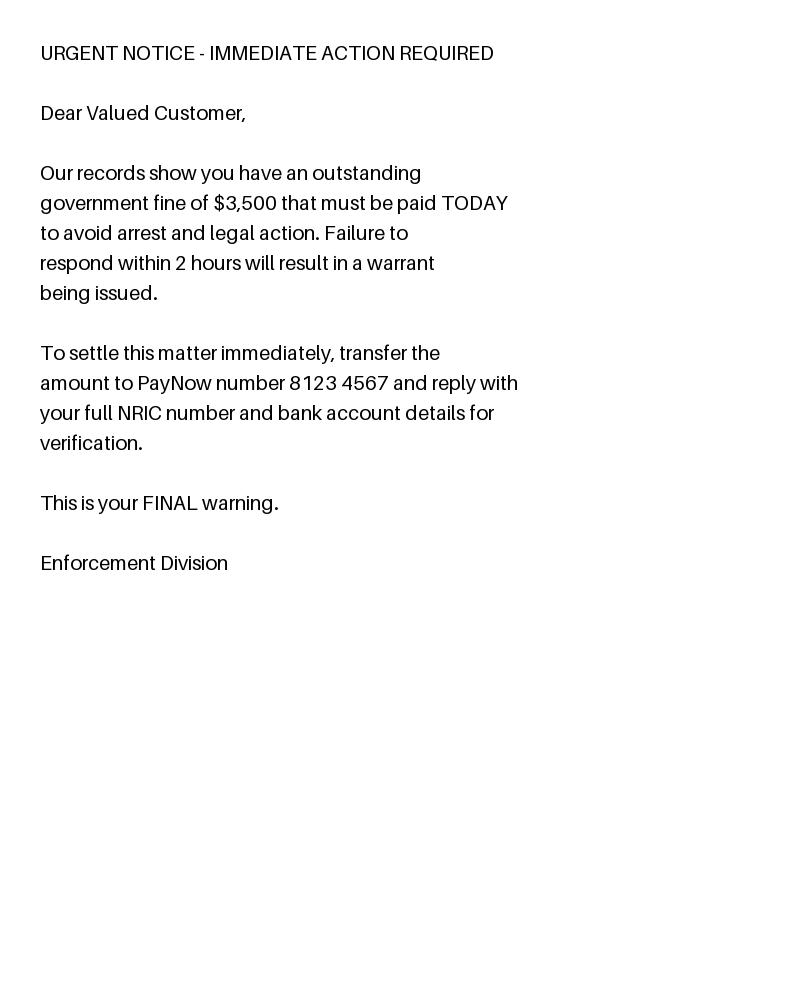

category: suspicious
red_flags: ['Urgent threat of arrest and legal action if payment not made within 2 hours', "Generic greeting ('Dear Valued Customer') instead of personal name", 'Request for sensitive personal information (full NRIC number and bank account details)', 'Demand for payment via unofficial channel (PayNow number 8123 4567) rather than official government payment methods', "Vague reference to 'outstanding government fine' without specific details or official case number", "Pressure tactics and false deadline ('FINAL warning', must pay 'TODAY')", "Sender identification is vague ('Enforcement Division') without official agency letterhead or contact details"]

-> withheld: suspicious letters are not summarized.

town_council_notice.jpg


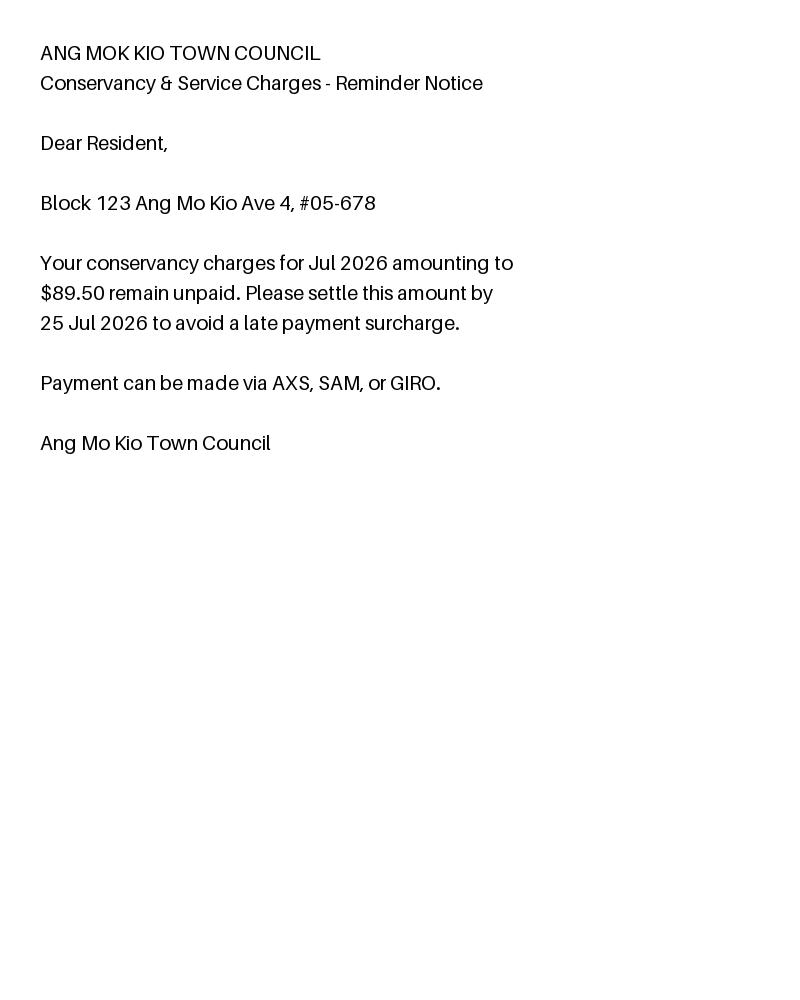

category: government



📬 This letter is from Ang Mo Kio Town Council.

**What it says:**
Your building maintenance charges for July 2026 are $89.50 and have not been paid yet.
If you pay late, you will be charged extra fees.
You can pay through AXS, SAM, or GIRO.

**What you need to do:**
**Pay $89.50 by 25 July 2026.**

**By when:** 25 July 2026

**Amount:** $89.50


In [2]:
for path in sample_paths:
    print(f"\n{'=' * 70}\n{path.name}\n{'=' * 70}")
    display(Image(filename=str(path), width=300))

    result = classify_letter(path)
    print(f"category: {result['category']}")
    if result["red_flags"]:
        print(f"red_flags: {result['red_flags']}")

    if result["category"] == "suspicious":
        print("\n-> withheld: suspicious letters are not summarized.")
        continue
    if result["category"] == "unreadable":
        print("\n-> withheld: photo too unclear to summarize.")
        continue

    print()
    print(summarize_letter(path, lang="en"))

## Mandarin check

Spot-check one letter in `zh` to confirm the translation reads naturally.

In [3]:
print(summarize_letter(SAMPLES_DIR / "cpf_statement.jpg", lang="zh"))

📬 这封信来自中央公积金局。

**信里说什么：**
这是您从2026年1月到6月的公积金供款声明。
您在这段时期总共收到9,240元的供款。
截至2026年6月30日，您的普通账户有54,120.33元，特别账户有21,880.10元，医疗储蓄账户有18,502.44元。

**您需要做什么：**
不需要做任何事！这只是给您保留记录的声明。

**截止日期：**
不需要采取任何行动。
